# EBSD α-field CWT Consistency Test
*FD vs wavelet-first-derivative vs wavelet-second-derivative sanity checks*

This notebook builds the per-grain demeaned log-rotation field (`combined_log`) and
then compares three ways of producing the Nye α-tensor Jacobian:

1. **Finite difference** directly on `combined_log` (pointwise `np.gradient`).
2. **CWT first derivative** (`derivs='first'`) — wavelet κ at multiple scales → α.
3. **CWT wavelet Hessian** (`derivs='all'`) — second-order wavelet derivatives directly,
   vs `np.gradient` applied on top of CWT α.

No singularity-spectrum computation here — these are **structural field-level sanity
checks** to confirm Pantleon Eq. 11/13 index conventions and the scale behavior of
the wavelet-framework outputs before committing to any production-pipeline refactor.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fftfreq
import ipywidgets as widgets
from IPython.display import display
import sys

import mlx.core as mx

sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm

print(f"MLX: {mx.__version__}, xsmurf: {xsm.__version__}")
# --- Shear-zone additions ---
try:
    from orix.quaternion import Orientation, Rotation
    from orix.quaternion.symmetry import D2, D3, C1
    _HAS_ORIX = True
    print(f'orix available for rotation + symmetry ops')
except ImportError:
    _HAS_ORIX = False
    print('orix not in this env — rotation + KAM fall back to pure-numpy path')

JOSEPHINE_ROTATION_XLSX = Path('EBSD/Josephine_Peridotite_Olivine/1365-3_RotationMetadata.xlsx')
EBSD_DIR = Path('/Users/amasaryk/projects/Creep/wavelet/EBSD')


MLX: 0.31.1, xsmurf: 0.1.0
orix available for rotation + symmetry ops


In [2]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')


CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined


In [3]:
%matplotlib widget


In [4]:
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf (Channel Text File) EBSD dataset.
    
    Returns
    -------
    data : dict with 2D arrays for each field + metadata dict
    """
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()

    meta = {'filepath': str(filepath), 'name': filepath.stem}
    phases = {}
    header_line = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith('XCells'):
            meta['xcells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('YCells'):
            meta['ycells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('XStep'):
            meta['xstep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('YStep'):
            meta['ystep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('Phases'):
            n_phases = int(stripped.split('\t')[1])
            for j in range(1, n_phases + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = n_phases
        elif stripped.startswith('Phase\tX\tY'):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"Could not find data header in {filepath}")

    # Read tabular data
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, engine='python',
                     on_bad_lines='skip')
    
    nx, ny = meta['xcells'], meta['ycells']
    expected = nx * ny
    actual = len(df)
    if actual != expected:
        print(f"  Warning: expected {expected} rows ({nx}x{ny}), got {actual}")
        # Truncate or pad
        if actual > expected:
            df = df.iloc[:expected]
        else:
            nx_adj = actual // ny if ny > 0 else nx
            meta['xcells'] = nx_adj
            nx = nx_adj

    data = {'meta': meta}
    shape = (ny, nx)
    for col in df.columns:
        try:
            data[col] = df[col].values.reshape(shape)
        except ValueError:
            data[col] = df[col].values  # keep flat if reshape fails

    # Convenience aliases
    data['euler1'] = data.get('Euler1', None)
    data['euler2'] = data.get('Euler2', None)
    data['euler3'] = data.get('Euler3', None)
    data['bc'] = data.get('BC', None)
    data['bs'] = data.get('BS', None)
    data['mad'] = data.get('MAD', None)
    data['phase'] = data.get('Phase', None)

    print(f"  Loaded {filepath.name}: {nx} x {ny}, step={meta.get('xstep','?')} µm, "
          f"{meta.get('n_phases','?')} phases")
    return data
# --- Oxford Instruments Channel 5 .cpr/.crc binary reader ---
# Pure-numpy reader for .cpr (ASCII INI metadata) + .crc (binary data) pairs.
# Field code mapping taken from defdap.file_readers.OxfordBinaryLoader source.
# Unlike defdap's loader, this one does NOT construct a crystal Phase object
# so it works for any Laue group (including trigonal quartz, monoclinic
# feldspars, etc.) that the narrow defdap Phase class would reject.

import re as _re_cpr

_CPR_FIELD_LOOKUP = {
    3:  ('ph1',      'float32'),   # Euler1 phi1 (rad)
    4:  ('phi',      'float32'),   # Euler2 Phi  (rad)
    5:  ('ph2',      'float32'),   # Euler3 phi2 (rad)
    6:  ('MAD',      'float32'),   # mean angular deviation
    7:  ('BC',       'uint8'),     # band contrast
    8:  ('BS',       'uint8'),     # band slope
    10: ('numBands', 'uint8'),
    11: ('AFI',      'uint8'),
    12: ('IB6',      'float32'),
}


def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}
    current = None
    group_re = _re_cpr.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'):
            continue
        m = group_re.match(line)
        if m:
            current = m.group(1)
            groups.setdefault(current, {})
            continue
        if current is None:
            continue
        if '=' in line:
            k, v = line.split('=', 1)
            groups[current][k.strip()] = v.strip()
    return groups


def read_cpr(filepath):
    """Read an Oxford Instruments .cpr/.crc file pair.

    Returns the same dict shape as read_ctf():
        meta          dict with xcells, ycells, xstep, ystep, phases, n_phases, name
        euler1/2/3    (ny, nx) float32 arrays in DEGREES
        phase         (ny, nx) uint8 array
        bc, bs, mad   (ny, nx) arrays if present
        Plus any EDX windows as EDX_<element> keys.
    """
    filepath = Path(filepath)
    cpr_path = filepath.with_suffix('.cpr')
    crc_path = filepath.with_suffix('.crc')
    if not cpr_path.exists():
        raise FileNotFoundError(f"CPR header not found: {cpr_path}")
    if not crc_path.exists():
        raise FileNotFoundError(f"CRC binary not found: {crc_path}")

    groups = _parse_cpr_ini(cpr_path)

    # Grid & step
    job = groups.get('Job', {})
    nx = int(job['xCells'])
    ny = int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))

    # Phases: assemble ctf-like metadata so downstream cells keep working
    pg = groups.get('Phases', {})
    n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = groups.get(f'Phase{i}', {})
        lattice = '{};{};{}'.format(pi.get('a', '?'), pi.get('b', '?'), pi.get('c', '?'))
        angles = '{};{};{}'.format(pi.get('alpha', '?'), pi.get('beta', '?'), pi.get('gamma', '?'))
        phases[i] = [lattice, angles,
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]

    # EDX window names (field codes 100+i)
    edx_names = {}
    edx_group = groups.get('EDX Windows', {})
    if edx_group:
        n_edx = int(edx_group.get('Count', 0))
        for i in range(1, n_edx + 1):
            key = edx_group.get(f'Window{i}', f'edx{i}')
            edx_names[100 + i] = key

    # Build the binary record dtype from the [Fields] section
    fg = groups.get('Fields', {})
    n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]   # phase is always first, uint8
    unknown = 0
    for i in range(1, n_fields + 1):
        code = int(fg[f'Field{i}'])
        if code in _CPR_FIELD_LOOKUP:
            dtype_items.append(_CPR_FIELD_LOOKUP[code])
        elif code in edx_names:
            dtype_items.append((f'EDX_{edx_names[code]}', 'float32'))
        else:
            unknown += 1
            dtype_items.append((f'unknown_{unknown}_code{code}', 'float32'))
            print(f'  warning: unknown CPR field code {code}, guessing float32')
    record_dtype = np.dtype(dtype_items)

    # Load binary
    raw = np.fromfile(str(crc_path), dtype=record_dtype, count=nx * ny)
    if raw.size != nx * ny:
        raw = raw[:nx * ny]
        print(f'  warning: CRC short read ({raw.size} records)')

    shape = (ny, nx)
    data = {'meta': {
        'filepath': str(filepath),
        'name': filepath.stem,
        'xcells': nx, 'ycells': ny,
        'xstep': xstep, 'ystep': ystep,
        'phases': phases, 'n_phases': n_phases,
        'format': 'cpr',
    }}

    data['phase'] = raw['phase'].reshape(shape)

    # CPR stores Euler in radians; convert to degrees to match ctf convention
    for raw_key, deg_key in [('ph1', 'euler1'), ('phi', 'euler2'), ('ph2', 'euler3')]:
        if raw_key in raw.dtype.names:
            data[deg_key] = np.rad2deg(raw[raw_key].reshape(shape)).astype(np.float32)

    if 'MAD' in raw.dtype.names: data['mad'] = raw['MAD'].reshape(shape)
    if 'BC'  in raw.dtype.names: data['bc']  = raw['BC'].reshape(shape)
    if 'BS'  in raw.dtype.names: data['bs']  = raw['BS'].reshape(shape)
    if 'numBands' in raw.dtype.names: data['bands'] = raw['numBands'].reshape(shape)
    for name in raw.dtype.names:
        if name.startswith('EDX_'):
            data[name] = raw[name].reshape(shape)

    print(f'  CPR: {nx}x{ny} @ {xstep} um, {n_phases} phases, {len(dtype_items)} fields')
    return data


def read_ebsd(filepath):
    """Dispatch to the right EBSD reader based on file extension."""
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    if ext == '.ctf':
        return read_ctf(filepath)
    elif ext in ('.cpr', '.crc'):
        return read_cpr(filepath)
    else:
        raise ValueError(f"Unsupported EBSD extension: {ext} (expected .ctf or .cpr/.crc)")


In [5]:
EBSD_DIR = Path('EBSD')

# --- Loadable files: .ctf (ASCII) and .cpr (Oxford binary via read_cpr) ---
ctf_files = sorted(EBSD_DIR.rglob('*.ctf'))
cpr_files = sorted(EBSD_DIR.rglob('*.cpr'))
ebsd_files = sorted(ctf_files + cpr_files, key=lambda p: (p.parts[:-1], p.name))

# Shear-zone folder tags
SHEAR_ZONE_TAGS = {
    'Calamita_Elba_Quartzite':           ('[CAL]', 'Calamita quartzite'),
    'Kuckaus_Namibia_Feldspar_Mylonite': ('[KUC]', 'Kuckaus polymineralic mylonite'),
    'Josephine_Peridotite_Olivine':      ('[JOS]', 'Josephine peridotite'),
}

def _tag(path):
    rel = path.relative_to(EBSD_DIR)
    root = rel.parts[0] if rel.parts else ''
    return SHEAR_ZONE_TAGS.get(root, ('[...]', root))[0]

labels = []
for p in ebsd_files:
    rel = p.relative_to(EBSD_DIR)
    labels.append(f'{_tag(p)} {rel}  [{p.suffix[1:]}]')

print(f'Found {len(ebsd_files)} EBSD files ({len(ctf_files)} CTF + {len(cpr_files)} CPR):\n')
from collections import defaultdict
by_tag = defaultdict(list)
for i, p in enumerate(ebsd_files):
    by_tag[_tag(p)].append(i)
for tag, idxs in by_tag.items():
    print(f'  {tag}  ({len(idxs)} files)')
    for i in idxs:
        rel = ebsd_files[i].relative_to(EBSD_DIR)
        print(f'    [{i:3d}] {rel}  [{ebsd_files[i].suffix[1:]}]')
    print()


Found 61 EBSD files (54 CTF + 7 CPR):

  [...]  (24 files)
    [  0] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Processed.ctf  [ctf]
    [  1] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Raw.ctf  [ctf]
    [  2] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Processed.ctf  [ctf]
    [  3] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Raw.ctf  [ctf]
    [  4] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite.ctf  [ctf]
    [  5] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite_processed.ctf  [ctf]
    [  6] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_Original.ctf  [ctf]
    [  7] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ci.ctf  [ctf]
    [  8] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4cii.ctf  [ctf]
    [  9] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ciii.ctf  [ctf]
    [ 10] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4di.ctf  [ctf]
    [ 11] 2015-06-26_Pearce_Mark_13963v1/data/Twinn

In [6]:
# ---- Pick a dataset by index ----
DATASET_IDX = 33# <-- change this to select a different file

ebsd_path = ebsd_files[DATASET_IDX]
ctf_path = ebsd_path                        # alias: downstream cells look at ctf_path
print(f'Selected: {labels[DATASET_IDX]}')
print(f'  Path: {ebsd_path}')

ebsd = read_ebsd(ebsd_path)
meta = ebsd['meta']


Selected: [JOS] Josephine_Peridotite_Olivine/ctf_files/3923J13.ctf  [ctf]
  Path: EBSD/Josephine_Peridotite_Olivine/ctf_files/3923J13.ctf
  Loaded 3923J13.ctf: 833 x 273, step=15.0 µm, 7 phases


Phases: {np.int64(0): np.int64(57153), np.int64(1): np.int64(118720), np.int64(2): np.int64(46582), np.int64(3): np.int64(4378), np.int64(4): np.int64(576)}
Dominant phase: 1
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
Phase mask: 118720/227409 (52.2%)
Computing KAM (kernel=1)...
  Kernel=1 -> 3x3, 4 unique neighbor pairs
KAM: [0.0000, 116.6385] deg, median=0.4317


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_8694/1500603122.py:91: RuntimeWarning: invalid value encountered in divide
  kam = np.where(count > 0, kam / count, 0)


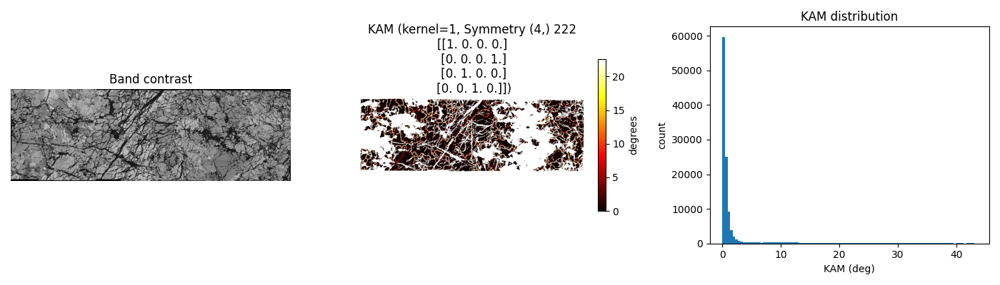

In [7]:
# ===== KAM via orix (symmetry-aware) =====

from orix.quaternion import Orientation
from orix.quaternion.symmetry import C1, C2, D2, D3, D6, C4, Oh

# ---------- USER PARAMETERS ----------
KAM_KERNEL = 1   # Kernel radius: 1 = 3x3, 2 = 5x5, 3 = 7x7, etc.
# --------------------------------------

LAUE_TO_ORIX = {
    '1': C1, '2': C2, '3': D2, '6': D3, '7': D6, '9': Oh, '11': C1,
}

def get_phase_symmetry(ebsd_data, phase_id=1):
    phases = ebsd_data['meta'].get('phases', {})
    if phase_id in phases:
        info = phases[phase_id]
        laue_str = str(info[3]).strip() if len(info) > 3 else '?'
        sym = LAUE_TO_ORIX.get(laue_str, None)
        name = info[2] if len(info) > 2 else f'phase_{phase_id}'
        print(f'  Phase {phase_id}: {name}, Laue={laue_str} -> {sym}')
        return sym
    return None


def compute_kam_orix(e1_deg, e2_deg, e3_deg, symmetry, mask=None,
                      kernel=1, degrees=True):
    """Compute KAM using orix Orientation.angle_with().

    kernel: neighborhood radius in pixels.
        1 = 3x3 (8 neighbors), 2 = 5x5 (24 neighbors), etc.
        Matches MTEX/OIM convention.
    """
    ny, nx = e1_deg.shape
    euler_rad = np.deg2rad(np.stack([e1_deg, e2_deg, e3_deg], axis=-1)).astype(np.float64)

    ori = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=symmetry)
    ori = ori.reshape(ny, nx)

    kam = np.zeros((ny, nx), dtype=np.float64)
    count = np.zeros((ny, nx), dtype=np.float64)

    if mask is None:
        mask = np.ones((ny, nx), dtype=bool)

    # Generate all (dy, dx) offsets within the kernel radius
    offsets = []
    for dy in range(-kernel, kernel + 1):
        for dx in range(-kernel, kernel + 1):
            if dy == 0 and dx == 0:
                continue
            # Only count each pair once: (dy,dx) and (-dy,-dx) are the same pair
            if (dy, dx) > (0, 0) or (dy == 0 and dx > 0):
                offsets.append((dy, dx))

    print(f'  Kernel={kernel} -> {2*kernel+1}x{2*kernel+1}, {len(offsets)} unique neighbor pairs')

    for dy, dx in offsets:
        # Slice pairs so ori1[i,j] is compared with ori2[i,j] = ori1[i+dy, j+dx]
        if dy >= 0:
            sy1 = slice(None, ny - dy) if dy > 0 else slice(None)
            sy2 = slice(dy, None) if dy > 0 else slice(None)
        else:
            sy1 = slice(-dy, None)
            sy2 = slice(None, ny + dy)

        if dx >= 0:
            sx1 = slice(None, nx - dx) if dx > 0 else slice(None)
            sx2 = slice(dx, None) if dx > 0 else slice(None)
        else:
            sx1 = slice(-dx, None)
            sx2 = slice(None, nx + dx)

        o1 = ori[sy1, sx1]
        o2 = ori[sy2, sx2]
        m = mask[sy1, sx1] & mask[sy2, sx2]

        if not m.any():
            continue

        angles = np.full(o1.shape, np.nan)
        angles[m] = o1[m].angle_with(o2[m])
        v = np.isfinite(angles)
        a = np.where(v, angles, 0)

        kam[sy1, sx1] += a
        kam[sy2, sx2] += a
        count[sy1, sx1] += v
        count[sy2, sx2] += v

    kam = np.where(count > 0, kam / count, 0)
    kam[~mask] = np.nan
    if degrees:
        kam = np.rad2deg(kam)
    return kam


# --- Compute KAM for current dataset ---
phase_map = ebsd['phase']
unique_phases, phase_counts = np.unique(phase_map, return_counts=True)
dominant_phase = unique_phases[np.argmax(phase_counts)]
print(f'Phases: {dict(zip(unique_phases, phase_counts))}')
print(f'Dominant phase: {dominant_phase}')

sym = get_phase_symmetry(ebsd, phase_id=dominant_phase)
if sym is None:
    for pid in unique_phases:
        sym = get_phase_symmetry(ebsd, phase_id=int(pid))
        if sym is not None:
            dominant_phase = int(pid)
            break
if sym is None:
    print('WARNING: could not determine symmetry, using C1')
    sym = C1

phase_mask = (phase_map == dominant_phase)
print(f'Phase mask: {phase_mask.sum()}/{phase_mask.size} ({phase_mask.mean():.1%})')

print(f'Computing KAM (kernel={KAM_KERNEL})...')
kam = compute_kam_orix(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                        symmetry=sym, mask=phase_mask,
                        kernel=KAM_KERNEL, degrees=True)
print(f'KAM: [{np.nanmin(kam):.4f}, {np.nanmax(kam):.4f}] deg, median={np.nanmedian(kam):.4f}')

ny, nx = kam.shape
aspect = ny / nx
fig_w = 14
fig_h = max(4, fig_w * aspect * 0.45)

fig, axes = plt.subplots(1, 3, figsize=(fig_w, fig_h))
axes[0].imshow(ebsd['bc'], cmap='gray', aspect='equal')
axes[0].set_title('Band contrast')
im = axes[1].imshow(kam, cmap='hot', vmin=0, vmax=np.nanpercentile(kam, 95), aspect='equal')
axes[1].set_title(f'KAM (kernel={KAM_KERNEL}, {sym})')
plt.colorbar(im, ax=axes[1], label='degrees', shrink=0.7)
axes[2].hist(kam[np.isfinite(kam)].ravel(), bins=100,
             range=(0, np.nanpercentile(kam, 99)))
axes[2].set(xlabel='KAM (deg)', ylabel='count', title='KAM distribution')
for ax in axes[:2]: ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# ===== Quaternion helpers (shared) =====
def _quat_mul(a, b):
    """Hamilton product.  Broadcasts over leading dims.  Last dim = 4 (w, x, y, z)."""
    aw, ax, ay, az = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bw, bx, by, bz = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([
        
        aw * bw - ax * bx - ay * by - az * bz,
        aw * bx + ax * bw + ay * bz - az * by,
        aw * by - ax * bz + ay * bw + az * bx,
        aw * bz + ax * by - ay * bx + az * bw,
    ], axis=-1)

def _quat_conj(q):
    out = q.copy()
    out[..., 1:] *= -1.0
    return out


## Grain identification (adjacency flood-fill, no kernels)

In [11]:
# ===== Grain identification via symmetry-aware adjacency flood-fill =====
# No kernels / windows: pixel neighbors only.  scipy.ndimage.label on a
# "same grain" adjacency graph built from per-neighbor misorientation.

from scipy.ndimage import label as ndi_label

# ---- parameters ----
GRAIN_THETA_DEG   = 5.0  # high-angle GB threshold (deg); 2 deg for subgrains
GRAIN_MIN_PIXELS  = 25    # drop grains smaller than this (stats only)
# ---------------------

def _sym_miso_angle(q_a, q_b, sym_q):
    """Symmetry-reduced misorientation angle between two quaternion arrays.
    q_a, q_b: (N, 4) unit quaternions.  sym_q: (S, 4) symmetry ops.
    Returns (N,) angles in radians (smallest under the point group)."""
    q_rel = _quat_mul(_quat_conj(q_a), q_b)           # (N, 4)
    q_sym = _quat_mul(q_rel[:, None, :], sym_q[None, :, :])  # (N, S, 4)
    w = np.abs(q_sym[..., 0])                         # (N, S)
    w_max = np.clip(w.max(axis=1), -1.0, 1.0)
    return 2.0 * np.arccos(w_max)

def identify_grains(ebsd_data, theta_c_deg=GRAIN_THETA_DEG):
    """Symmetry-aware grain segmentation.
    Returns: grain_id (ny, nx) int32 (0 = unindexed/background, ≥1 = grain id).
    Algorithm:
      - for each phase, compute pixel-right and pixel-down misorientation (adjacency only)
      - threshold to build 'same grain' edge graph
      - connected-components label within phase
      - concatenate grain ids across phases with unique offsets
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    # Build unit quaternion map (from Euler via orix)
    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q *= np.where(q[..., 0:1] >= 0, 1.0, -1.0)

    theta_c = np.deg2rad(theta_c_deg)
    grain_id = np.zeros((ny, nx), dtype=np.int32)
    gid_offset = 0

    for pid in [int(p) for p in np.unique(phase) if int(p) > 0]:
        pmask = (phase == pid)
        if pmask.sum() < GRAIN_MIN_PIXELS:
            continue
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        # Right-neighbor misorientation: between (y, x) and (y, x+1)
        a = q[:, :-1, :].reshape(-1, 4)
        b = q[:,  1:, :].reshape(-1, 4)
        theta_right = _sym_miso_angle(a, b, sym_q).reshape(ny, nx - 1)

        # Down-neighbor misorientation: between (y, x) and (y+1, x)
        a = q[:-1, :, :].reshape(-1, 4)
        b = q[ 1:, :, :].reshape(-1, 4)
        theta_down = _sym_miso_angle(a, b, sym_q).reshape(ny - 1, nx)

        # Build same-phase adjacency: both pixels must be in this phase
        both_r = pmask[:, :-1] & pmask[:, 1:]
        both_d = pmask[:-1, :] & pmask[1:, :]

        # Same-grain edges
        same_r = both_r & (theta_right < theta_c)
        same_d = both_d & (theta_down  < theta_c)

        # Expand edge flags to a 4-connected adjacency-friendly mask:
        # a pixel is "connected to its right/down neighbor" iff same_r/same_d is True.
        # scipy.ndimage.label can use a custom structure on a binary image, but we
        # want connectivity conditional on edge labels.  Easiest: build a pseudo-pixel
        # structure by union-find over edges.
        # Use a lightweight Union-Find implementation.
        n_pix = ny * nx
        parent = np.arange(n_pix, dtype=np.int64)

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        def union(i, j):
            ri, rj = find(i), find(j)
            if ri != rj:
                parent[rj] = ri

        ys, xs = np.where(same_r)
        for y, x in zip(ys, xs):
            union(y * nx + x, y * nx + (x + 1))

        ys, xs = np.where(same_d)
        for y, x in zip(ys, xs):
            union(y * nx + x, (y + 1) * nx + x)

        # Harvest roots → local labels
        roots = np.array([find(i) for i in range(n_pix)], dtype=np.int64)
        # Only keep labels inside phase mask
        ravel_mask = pmask.ravel()
        # Remap roots to 1..K
        uniq_roots, inv = np.unique(roots[ravel_mask], return_inverse=True)
        local_lbl = np.zeros(n_pix, dtype=np.int32)
        local_lbl[ravel_mask] = inv.astype(np.int32) + 1
        local_lbl = local_lbl.reshape(ny, nx)

        # Offset and assign
        n_this = int(local_lbl.max())
        lbl_off = np.where(local_lbl > 0, local_lbl + gid_offset, 0)
        grain_id[pmask] = lbl_off[pmask]
        gid_offset += n_this

    return grain_id


# ---- Run ----
grain_id = identify_grains(ebsd, theta_c_deg=GRAIN_THETA_DEG)
n_grains_total = int(grain_id.max())
sizes = np.bincount(grain_id.ravel())[1:]  # skip background
n_big = int((sizes >= GRAIN_MIN_PIXELS).sum())
print(f'Grains found: {n_grains_total} total, {n_big} with >= {GRAIN_MIN_PIXELS} px')
print(f'Median grain size: {int(np.median(sizes)) if len(sizes) else 0} px, '
      f'max: {int(sizes.max()) if len(sizes) else 0} px')


  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 2: Orthopyroxene, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 3: Diopside, Laue=2 -> Symmetry (2,) 2
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]]
  Phase 4: Chromite, Laue=11 -> Symmetry (1,) 1
[[1. 0. 0. 0.]]
Grains found: 4278 total, 776 with >= 25 px
Median grain size: 2 px, max: 4713 px


## Per-grain demean + log orientation

In [12]:
# ===== Per-grain Karcher mean + demean + log orientation =====
# Per-grain symmetry-aware mean reference; log map reduces to FZ.

# ---- options ----
CAXIS_TO_Z = True     # rotate each grain reference so c-axis || sample Z (quartz only)
FZ_WARN_FRAC = 0.7    # warn when per-pixel disorientation exceeds this fraction of FZ max
# -----------------

# FZ max disorientation (deg) per point group (approximate, proper rotation group)
FZ_MAX_DEG_BY_NAME = {
    'D6h': 93.8, 'D6': 93.8, 'C6h': 93.8, 'C6': 93.8,
    'D4h': 98.4, 'D4': 98.4, 'C4h': 98.4, 'C4': 98.4,
    'D3d': 104.5, 'D3': 104.5, 'C3v': 104.5, 'C3': 120.0,
    'D2h': 120.7, 'D2': 120.7, 'C2h': 180.0, 'C2': 180.0,
    'Ci':  180.0, 'C1':  180.0,
    'Oh':  62.8, 'O':  62.8, 'Td': 62.8, 'Th': 62.8, 'T': 62.8,
    'S6':  180.0, 'S4': 180.0, 'Cs':  180.0,
}

def _karcher_mean_grain(q_grain, sym_q, max_iter=5, tol=1e-4):
    """Symmetry-aware Karcher mean of unit quaternions within a grain."""
    n = len(q_grain)
    q_grain = q_grain * np.where(q_grain[:, 0:1] >= 0, 1.0, -1.0)
    # Seed = orientation tensor dominant eigenvector
    T = (q_grain.T @ q_grain) / n
    _, eigvecs = np.linalg.eigh(T)
    q_ref = eigvecs[:, -1]
    if q_ref[0] < 0:
        q_ref = -q_ref
    for _ in range(max_iter):
        # Choose symmetry-equivalent closest to q_ref for each pixel
        q_sym = _quat_mul(q_grain[:, None, :], sym_q[None, :, :])  # (N, S, 4)
        rel = _quat_mul(_quat_conj(q_ref)[None, None, :], q_sym)
        rel *= np.where(rel[..., 0:1] >= 0, 1.0, -1.0)
        best = np.argmax(rel[..., 0], axis=1)
        q_aligned = q_sym[np.arange(n), best]
        q_aligned *= np.where(q_aligned[:, 0:1] >= 0, 1.0, -1.0)
        T = (q_aligned.T @ q_aligned) / n
        _, eigvecs = np.linalg.eigh(T)
        q_new = eigvecs[:, -1]
        if q_new[0] < 0:
            q_new = -q_new
        if abs(float(q_ref @ q_new)) > 1.0 - tol:
            break
        q_ref = q_new
    return q_ref, q_aligned

def _rotation_to_align_caxis_with_z(q_ref):
    """Return quaternion r such that (r * q_ref) places crystal c-axis along sample Z.
    Crystal c-axis in crystal frame = (0, 0, 1).  Rotate crystal frame by q_ref
    into sample frame; we then want r so that r composed with the rotated c-axis
    points along sample Z.  Implementation: compute rotated c-axis, then rigid
    rotation bringing that vector to (0, 0, 1)."""
    # Rotate (0, 0, 1) by q_ref: v = q_ref * (0,0,0,1) * q_ref^-1
    w, x, y, z = q_ref
    # Quaternion rotation of unit z-axis:
    vx = 2.0 * (x * z + w * y)
    vy = 2.0 * (y * z - w * x)
    vz = 1.0 - 2.0 * (x * x + y * y)
    v = np.array([vx, vy, vz])
    v /= np.linalg.norm(v) + 1e-12
    z_axis = np.array([0.0, 0.0, 1.0])
    cosang = float(np.clip(v @ z_axis, -1.0, 1.0))
    if cosang > 1.0 - 1e-9:
        return np.array([1.0, 0.0, 0.0, 0.0])
    if cosang < -1.0 + 1e-9:
        return np.array([0.0, 1.0, 0.0, 0.0])  # 180 deg about x
    axis = np.cross(v, z_axis)
    axis /= np.linalg.norm(axis) + 1e-12
    ang = np.arccos(cosang)
    s = np.sin(ang / 2.0)
    return np.array([np.cos(ang / 2.0), axis[0] * s, axis[1] * s, axis[2] * s])

def compute_log_orientation_per_grain(ebsd_data, grain_id, caxis_to_z=CAXIS_TO_Z):
    """Per-grain demean + log map.
    Returns dict: grain_id -> {q_ref, q_align_rot, log_field_slice, mask, phase_id,
                                theta_p99_deg, fz_max_deg, fz_warn}
    Also returns a combined (ny, nx, 3) log field with per-grain demeaned values.
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q_map = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q_map *= np.where(q_map[..., 0:1] >= 0, 1.0, -1.0)

    combined_log = np.zeros((ny, nx, 3), dtype=np.float32)
    combined_mask = np.zeros((ny, nx), dtype=bool)
    grain_info = {}

    gids = [int(g) for g in np.unique(grain_id) if int(g) > 0]
    print(f'Processing {len(gids)} grains...')

    for gi, gid in enumerate(gids):
        gmask = (grain_id == gid)
        n_pix = int(gmask.sum())
        if n_pix < GRAIN_MIN_PIXELS:
            continue
        ys, xs = np.where(gmask)
        pid = int(phase[ys[0], xs[0]])
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        q_grain = q_map[ys, xs, :]            # (n, 4)
        q_ref, q_aligned = _karcher_mean_grain(q_grain, sym_q)

        # Optional rigid rotation bringing c-axis || Z
        if caxis_to_z:
            r = _rotation_to_align_caxis_with_z(q_ref)
            # Apply r to q_ref and to aligned pixels: q' = r * q
            q_ref_new  = _quat_mul(r[None, :], q_ref[None, :])[0]
            q_aligned_new = _quat_mul(r[None, :], q_aligned)
        else:
            r = np.array([1.0, 0.0, 0.0, 0.0])
            q_ref_new = q_ref
            q_aligned_new = q_aligned

        # Disorientation: q_rel = q_ref^-1 * q_aligned  (already picked symmetry rep)
        rel = _quat_mul(_quat_conj(q_ref_new)[None, :], q_aligned_new)
        rel *= np.where(rel[:, 0:1] >= 0, 1.0, -1.0)
        w = np.clip(rel[:, 0], -1.0, 1.0)
        theta = 2.0 * np.arccos(w)
        sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
        small = sin_half < 1e-8
        safe = np.where(small, 1.0, sin_half)
        axis = rel[:, 1:4] / safe[:, None]
        axis[small] = 0.0
        omega = theta[:, None] * axis
        omega[small] = 2.0 * rel[small, 1:4]

        combined_log[ys, xs, :] = omega.astype(np.float32)
        combined_mask[ys, xs]   = True

        # FZ validity check
        sym_name = sym.__class__.__name__ if sym is not None else 'C1'
        fz_max = FZ_MAX_DEG_BY_NAME.get(sym_name, 180.0)
        p99 = float(np.rad2deg(np.percentile(theta, 99))) if n_pix else 0.0
        fz_warn = bool(p99 > FZ_WARN_FRAC * fz_max)

        grain_info[gid] = {
            'phase_id': pid,
            'n_pixels': n_pix,
            'q_ref': q_ref_new,
            'rot_to_z': r,
            'theta_p99_deg': p99,
            'fz_max_deg': fz_max,
            'fz_warn': fz_warn,
            'sym_name': sym_name,
        }

    n_warn = sum(1 for g in grain_info.values() if g['fz_warn'])
    if n_warn:
        print(f'  WARNING: {n_warn} grain(s) near FZ boundary (log chart may be unreliable).')
        print('  Consider splitting via subgrain segmentation (theta_c = 2 deg).')

    return combined_log, combined_mask, grain_info


combined_log, combined_mask, grain_info = compute_log_orientation_per_grain(
    ebsd, grain_id, caxis_to_z=CAXIS_TO_Z)
print(f'Combined per-grain log field: {combined_mask.sum()}/{combined_mask.size} pixels')
print(f'log_field  abs median: {np.median(np.abs(combined_log[combined_mask])):.4f}')
print(f'log_field  abs p99:    {np.percentile(np.abs(combined_log[combined_mask]), 99):.4f}')


Processing 4278 grains...
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Phase 1: Forsterite, Laue=3 -> Symmetry (4,) 222
[[1. 0. 0. 0.]
 [0. 0. 0. 1

## FD vs CWT Test Bench

Starting from `combined_log` produced by the demeaning cell above.


### Cell A — FD κ and α (ground truth, no wavelet)


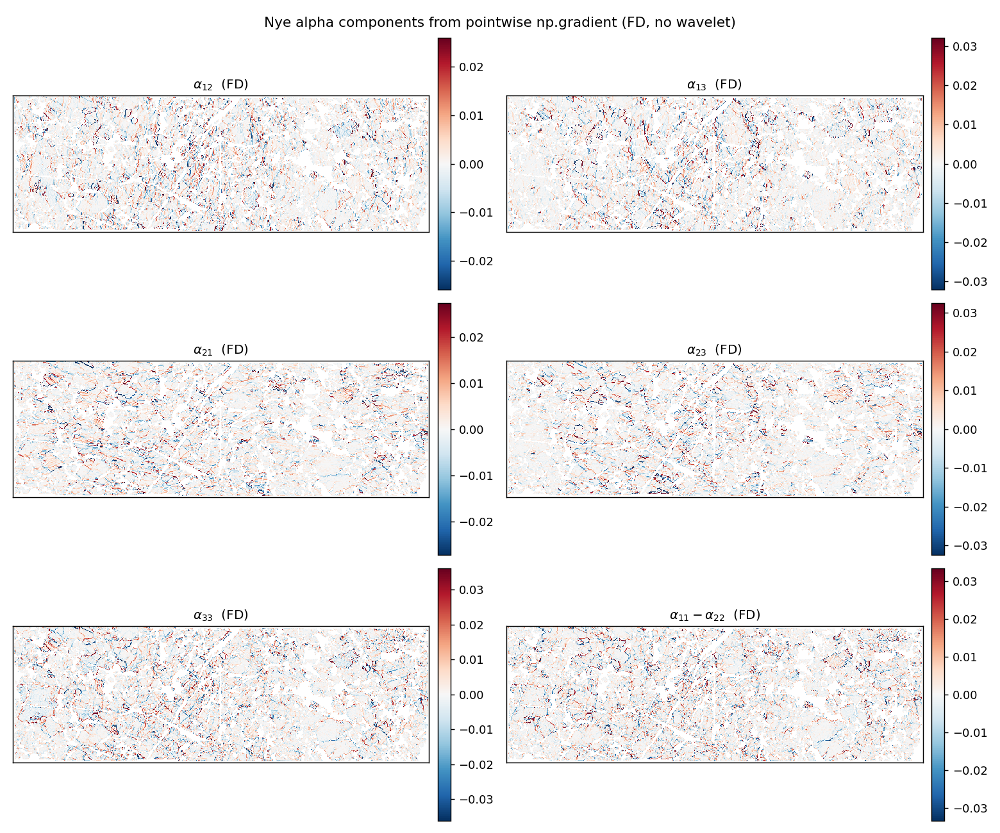

kappa_fd, alpha_fd built with shapes (273, 833).
combined_mask covers 157488/227409 pixels.


In [13]:
# ===== Cell A: Finite-difference kappa_ij and Nye alpha components =====
# Pointwise np.gradient on the demeaned rotation vector field combined_log.
# This is the "ground truth" discretisation of Pantleon's kappa_ij = d g_i / d x_j
# at the raw EBSD grid resolution (no wavelet smoothing).

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# kappa_fd[(i, j)] where i in {1,2,3} = rotation component, j in {1,2} = spatial direction
kappa_fd = {}
for ci in range(3):
    kappa_fd[(ci + 1, 1)] = np.gradient(combined_log[..., ci], axis=1).astype(np.float32)   # d/dx
    kappa_fd[(ci + 1, 2)] = np.gradient(combined_log[..., ci], axis=0).astype(np.float32)   # d/dy

# Pantleon 2008 Eqs. 11 & 13 (zero-elastic-strain)
alpha_fd = {
    'a12':     kappa_fd[(2, 1)],
    'a13':     kappa_fd[(3, 1)],
    'a21':     kappa_fd[(1, 2)],
    'a23':     kappa_fd[(3, 2)],
    'a33':   -(kappa_fd[(1, 1)] + kappa_fd[(2, 2)]),
    'a11_a22': kappa_fd[(1, 1)] - kappa_fd[(2, 2)],
}

# --- Visualize: Pantleon 2008 Fig. 2 style, from FD
_labels = [
    (r'$\alpha_{12}$',                          'a12'),
    (r'$\alpha_{13}$',                          'a13'),
    (r'$\alpha_{21}$',                          'a21'),
    (r'$\alpha_{23}$',                          'a23'),
    (r'$\alpha_{33}$',                          'a33'),
    (r'$\alpha_{11}-\alpha_{22}$',             'a11_a22'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=130)
for ax, (lbl, key) in zip(axes.flat, _labels):
    f = alpha_fd[key].astype(np.float64).copy()
    if 'combined_mask' in globals():
        f = np.where(combined_mask, f, np.nan)
    vmax = float(np.nanpercentile(np.abs(f), 99))
    if not np.isfinite(vmax) or vmax <= 0: vmax = 1e-12
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    im = ax.imshow(f, cmap='RdBu_r', norm=norm, origin='upper',
                   aspect='equal', interpolation='nearest')
    ax.set_title(lbl + '  (FD)', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
fig.suptitle('Nye alpha components from pointwise np.gradient (FD, no wavelet)', fontsize=12)
fig.tight_layout()
plt.show()

print(f'kappa_fd, alpha_fd built with shapes {alpha_fd["a12"].shape}.')
print(f'combined_mask covers {int(combined_mask.sum())}/{combined_mask.size} pixels.')


In [14]:
# ===== Helper: scale-a Gaussian smoothing (matches cwt_2d_f32's kernel exactly) =====
# cwt_2d_f32 uses  gauss = exp(-(sx**2 + sy**2))  with  sx = kx * scale  (in Fourier).
# We replicate the same filter so a "scale-matched FD" comparison is apples-to-apples
# with the CWT output -- any remaining residual isolates the np.gradient approximation
# error from the smoothing effect.

def gauss_smooth_at_scale(field, scale):
    """Apply the same Fourier Gaussian kernel used by cwt_2d_f32 at the given scale.
    `field` is (ny, nx) real-valued.  Returns a real-valued array of the same shape."""
    ny, nx = field.shape
    ky = np.fft.fftfreq(ny, d=1.0).reshape(-1, 1) * 2.0 * np.pi
    kx = np.fft.fftfreq(nx, d=1.0).reshape(1, -1) * 2.0 * np.pi
    sx = kx * scale
    sy = ky * scale
    W = np.exp(-(sx * sx + sy * sy)).astype(np.float64)
    F = np.fft.fft2(field.astype(np.float64))
    return np.real(np.fft.ifft2(F * W)).astype(np.float32)

print('gauss_smooth_at_scale(field, scale) defined.')


gauss_smooth_at_scale(field, scale) defined.


### Cell B — CWT first-deriv κ and α at multiple scales


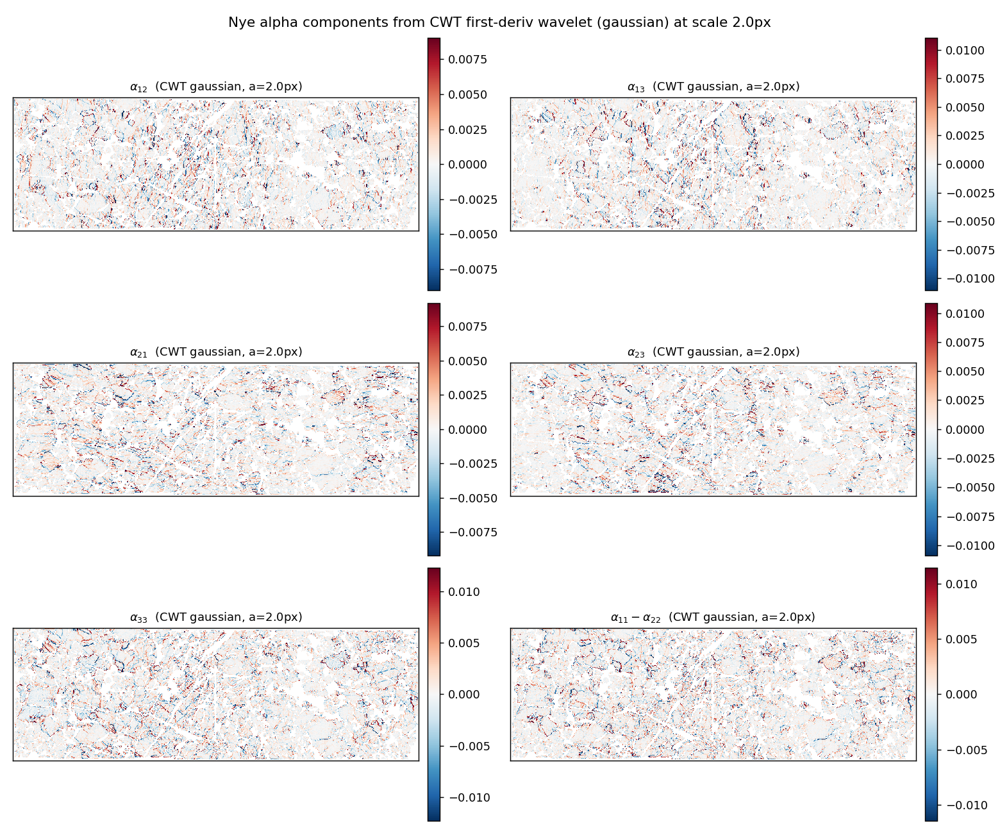

alpha_cwt stored at 5 scales: [2.0, 4.0, 8.0, 16.0, 32.0]


In [15]:
# ===== Cell B: CWT first-derivative at multiple scales -> wavelet-smoothed kappa / alpha =====
# Run cwt_2d_f32 (first-derivative mode) on each rotation component, then assemble
# Nye alpha at each scale via the same Pantleon mapping used in Cell A.

_scales_test = [2.0, 4.0, 8.0, 16.0, 32.0]
WAVELET_TEST = 'gaussian'   # start with pure gaussian (g1); Cell F redoes this with 'mexican'

derivs_first = [
    cwt_2d_f32(combined_log[..., c], _scales_test, pad=32,
               derivs='first', wavelet=WAVELET_TEST, verbose=False)
    for c in range(3)
]

def _alpha_from_derivs_first(D, si):
    """Build Nye alpha dict at scale index si from a 3-element CWT-first-deriv list."""
    k = {}
    for ci in range(3):
        k[(ci + 1, 1)] = D[ci]['dx'][si]
        k[(ci + 1, 2)] = D[ci]['dy'][si]
    return {
        'a12':     k[(2, 1)],
        'a13':     k[(3, 1)],
        'a21':     k[(1, 2)],
        'a23':     k[(3, 2)],
        'a33':   -(k[(1, 1)] + k[(2, 2)]),
        'a11_a22': k[(1, 1)] - k[(2, 2)],
    }

alpha_cwt = {si: _alpha_from_derivs_first(derivs_first, si)
             for si in range(len(_scales_test))}

# --- Visualize at smallest scale (si=0) for side-by-side with Cell A ---
SI_CMP = 0
fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=130)
for ax, (lbl, key) in zip(axes.flat, _labels):
    f = alpha_cwt[SI_CMP][key].astype(np.float64).copy()
    if 'combined_mask' in globals():
        f = np.where(combined_mask, f, np.nan)
    vmax = float(np.nanpercentile(np.abs(f), 99))
    if not np.isfinite(vmax) or vmax <= 0: vmax = 1e-12
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    im = ax.imshow(f, cmap='RdBu_r', norm=norm, origin='upper',
                   aspect='equal', interpolation='nearest')
    ax.set_title(lbl + f'  (CWT {WAVELET_TEST}, a={_scales_test[SI_CMP]:.1f}px)', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
fig.suptitle(f'Nye alpha components from CWT first-deriv wavelet ({WAVELET_TEST}) at scale {_scales_test[SI_CMP]:.1f}px',
             fontsize=12)
fig.tight_layout()
plt.show()

print(f'alpha_cwt stored at {len(_scales_test)} scales: {_scales_test}')


### Cell C — Spearman FD vs CWT over grain mask


In [16]:
# ===== Cell C: Raw-FD vs CWT spatial consistency =====
# Compare the pointwise FD gradient of combined_log (no wavelet smoothing)
# to the CWT first-deriv output at each test scale.  This is the SIMPLE test
# that Kestener-Arneodo / MBA literature implicitly perform: "does the CWT
# reproduce the FD gradient at the smallest wavelet scale, within the smoothing
# allowed by the wavelet?"
#
# Note: this mixes two smoothness levels by design -- alpha_fd is raw pixel FD,
# alpha_cwt[si] is wavelet-smoothed at scale a.  Spearman will DROP with
# increasing scale because of smoothing; at smallest a (approaching 1 px) it
# should approach 1 up to the np.gradient FD approximation error at Nyquist.

from scipy.stats import spearmanr

print(f'{"mode":<10} {"scale_px":<10} {"spearman(raw FD vs CWT)":<28}  {"ratio(CWT/FD) median":<22}')
print('-' * 72)
for key in ('a12', 'a13', 'a21', 'a23', 'a33', 'a11_a22'):
    for si, a in enumerate(_scales_test):
        ref  = alpha_fd[key]
        test = alpha_cwt[si][key]
        m = combined_mask
        rho, _ = spearmanr(ref[m], test[m])
        with np.errstate(divide='ignore', invalid='ignore'):
            denom = np.abs(ref[m]) + 1e-30
            ratio = float(np.median(np.abs(test[m]) / denom))
        print(f'{key:<10} {a:<10.1f} {rho:<28.4f}  {ratio:<22.4e}')
print()
print('Expected:  rho high at smallest scales (minimal smoothing),')
print('           dropping as scale grows (wavelet smooths away fine FD structure).')
print('           ratio grows with scale because CWT carries an a-prefactor from the')
print('           scale-normalised wavelet filter (see L1-normalisation note in Cell D).')


mode       scale_px   spearman(raw FD vs CWT)       ratio(CWT/FD) median  
------------------------------------------------------------------------
a12        2.0        0.8452                        4.0299e-01            
a12        4.0        0.7965                        4.6985e-01            
a12        8.0        0.5233                        6.4034e-01            
a12        16.0       0.3166                        7.9505e-01            
a12        32.0       0.1825                        7.6280e-01            
a13        2.0        0.8345                        4.0331e-01            
a13        4.0        0.7823                        4.6547e-01            
a13        8.0        0.5064                        6.3174e-01            
a13        16.0       0.3050                        8.0374e-01            
a13        32.0       0.1839                        8.0438e-01            
a21        2.0        0.8515                        4.0146e-01            
a21        4.0        0.799

### Cell D — Wavelet Hessian vs np.gradient on α_cwt


wavelet-Hessian (derivs='all', gaussian) vs np.gradient(alpha_cwt), full scale sweep
quantity                               scale_px   spearman      ratio_median  
----------------------------------------------------------------------------
d alpha_12 / d x1                      2.0        0.7855        6.4443e-01    
d alpha_23 / d x2                      2.0        0.7951        6.3640e-01    
d alpha_33 / d x1                      2.0        0.7852        6.0309e-01    
d alpha_12 / d x1                      4.0        0.9618        8.1816e-01    
d alpha_23 / d x2                      4.0        0.9638        8.1642e-01    
d alpha_33 / d x1                      4.0        0.9640        7.8880e-01    
d alpha_12 / d x1                      8.0        0.9978        1.3642e+00    
d alpha_23 / d x2                      8.0        0.9978        1.3647e+00    
d alpha_33 / d x1                      8.0        0.9981        1.3507e+00    
d alpha_12 / d x1                      16.0     

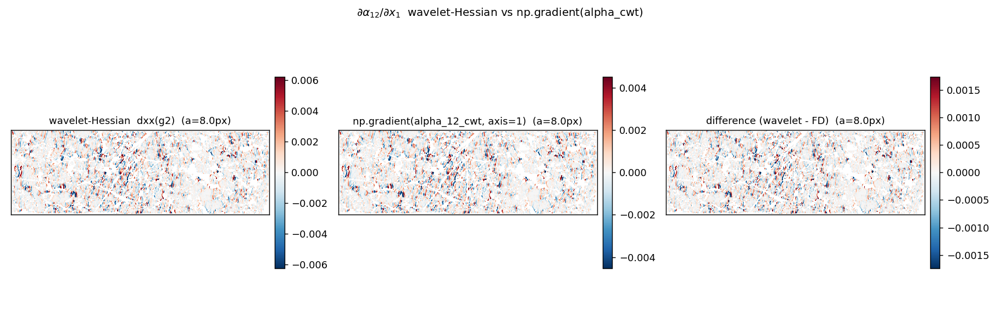

In [17]:
# ===== Cell D: Wavelet Hessian vs np.gradient(alpha_cwt) -- full scale sweep =====
# This is the real derivative-operator equivalence test: both sides are at the SAME
# smoothness (scale-a Gaussian). Only the differential operator differs.
#   wavelet-Hessian:        exact Fourier 2nd derivative via cwt_2d_f32(derivs='all')
#   np.gradient(alpha_cwt): central-difference finite approximation on top of CWT output.
# Test at multiple scales to see whether the magnitude ratio is scale-independent.
#
# ---- L1 normalisation note ----
# MBA / xsmurf WTMM uses L1-normalised wavelets: psi_a(x) = (1/a^d) psi(x/a).
# With L1 norm the wavelet coefficients scale as a^h at points of Holder regularity h,
# so the log-log slope of the modulus directly gives h.  cwt_2d_f32's Fourier filter
# exp(-|k*a|^2) corresponds to an L1-normalised spatial Gaussian (integral = 1).
# Its FIRST derivative filter  (i*sx * gauss)  therefore corresponds to L1 * d/dx,
# which carries an implicit a prefactor compared to the un-normalised derivative.
# Its SECOND derivative filter (-sx^2 * gauss) carries a^2.  Taking np.gradient of
# the first-derivative output only adds one more factor of a via its Fourier
# equivalent i*sin(kx)/h -> i*kx at low frequency.  Net expected:
#     ratio(wavelet-Hessian / np.gradient(alpha_cwt))  =  a^2 / a  =  a
# If cwt_2d_f32 internally divides by a to keep amplitudes comparable across scales,
# the effective ratio becomes a constant (independent of a) -- which is GOOD for
# WTMM extrema tracking and for the wavelet-Hessian refactor.
# The scale sweep below tells us which case applies.

WAVELET_HESSIAN = 'gaussian'   # pure second partials require gaussian (not mexican)
derivs_all = [
    cwt_2d_f32(combined_log[..., c], _scales_test, pad=32,
               derivs='all', wavelet=WAVELET_HESSIAN, verbose=False)
    for c in range(3)
]

from scipy.stats import spearmanr

print(f'wavelet-Hessian (derivs=\'all\', gaussian) vs np.gradient(alpha_cwt), full scale sweep')
print(f'{"quantity":<38} {"scale_px":<10} {"spearman":<12}  {"ratio_median":<14}')
print('-' * 76)

_test_specs = [
    ('d alpha_12 / d x1',    (1, 'dxx'), 'a12', 1),   # d2 g2 / dx2
    ('d alpha_23 / d x2',    (2, 'dyy'), 'a23', 0),   # d2 g3 / dy2
    ('d alpha_33 / d x1',    None,       'a33', 1),   # composite: -(dxx g1 + dxy g2)
]

ratios_by_name = {spec[0]: [] for spec in _test_specs}

for si, a in enumerate(_scales_test):
    for label, wav_spec, fd_key, fd_axis in _test_specs:
        if label == 'd alpha_33 / d x1':
            wav = -(derivs_all[0]['dxx'][si] + derivs_all[1]['dxy'][si])
        else:
            ci, dkey = wav_spec
            wav = derivs_all[ci][dkey][si]
        fd = np.gradient(alpha_cwt[si][fd_key], axis=fd_axis)
        m = combined_mask
        rho, _ = spearmanr(wav[m], fd[m])
        with np.errstate(divide='ignore', invalid='ignore'):
            denom = np.abs(fd[m]) + 1e-30
            ratio = float(np.median(np.abs(wav[m]) / denom))
        ratios_by_name[label].append(ratio)
        print(f'{label:<38} {a:<10.1f} {rho:<12.4f}  {ratio:<14.4e}')

# Summary: is the ratio scale-constant or does it grow with a?
print('\nRatio scaling summary (ratio at scale a vs scale a_ref=_scales_test[0]):')
print(f'{"quantity":<38} {"a=" + str(_scales_test[0]):<8} ' +
      ' '.join(f'a={a:<6.1f}' for a in _scales_test[1:]))
for label in ratios_by_name:
    rs = ratios_by_name[label]
    ref = rs[0] if rs and rs[0] > 0 else 1.0
    norm = [r / ref for r in rs]
    print(f'{label:<38} {norm[0]:<8.3f} ' + ' '.join(f'{n:<8.3f}' for n in norm[1:]))
print()
print('If the "ratio scaling summary" row is ~constant (all columns ~1.0), cwt_2d_f32')
print('normalises out the a-prefactor internally -- L1-compatible and safe to use for')
print('the wavelet-Hessian refactor.  If the ratios grow roughly linearly with a, the')
print('filters carry the bare a^n prefactors and we\'d need a 1/a calibration to match')
print('np.gradient(alpha_cwt) amplitudes (but Spearman would still be ~1 so the STRUCTURE')
print('is preserved and h is recovered from log-log slopes regardless).')

# Visual for one representative scale: si = middle
SI_VIZ = min(2, len(_scales_test) - 1)
a_viz = _scales_test[SI_VIZ]
da12_dx_wav = derivs_all[1]['dxx'][SI_VIZ]
da12_dx_fd  = np.gradient(alpha_cwt[SI_VIZ]['a12'], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=130)
for ax, (title, arr) in zip(axes,
                            [('wavelet-Hessian  dxx(g2)',        da12_dx_wav),
                             ('np.gradient(alpha_12_cwt, axis=1)', da12_dx_fd),
                             ('difference (wavelet - FD)',       da12_dx_wav - da12_dx_fd)]):
    f = arr.astype(np.float64).copy()
    if 'combined_mask' in globals():
        f = np.where(combined_mask, f, np.nan)
    vmax = float(np.nanpercentile(np.abs(f), 99))
    if not np.isfinite(vmax) or vmax <= 0: vmax = 1e-12
    im = ax.imshow(f, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='upper',
                   aspect='equal', interpolation='nearest')
    ax.set_title(title + f'  (a={a_viz:.1f}px)', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
fig.suptitle(r'$\partial \alpha_{12} / \partial x_1$  wavelet-Hessian vs np.gradient(alpha_cwt)',
             fontsize=11)
fig.tight_layout()
plt.show()


### Cell E — |α| scaling check


In [ ]:
# ===== Cell E: Log-log scaling check of mean |alpha| vs scale =====
# Quick sanity: alpha magnitudes should vary smoothly (and roughly power-law)
# with scale within a reasonable plateau. Departures indicate wavelet cutoff
# at very small a or plateau/support effects at very large a.

fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=130)
for key in ('a12', 'a13', 'a21', 'a23', 'a33', 'a11_a22'):
    means = []
    for si in range(len(_scales_test)):
        arr = alpha_cwt[si][key]
        means.append(float(np.mean(np.abs(arr[combined_mask]))))
    ax.plot(np.log2(_scales_test), np.log2(np.maximum(means, 1e-30)),
            'o-', label=key, ms=5)
ax.set(xlabel=r'$\log_2$(scale px)', ylabel=r'$\log_2\langle|\alpha|\rangle$',
       title=f'mean |alpha| scaling  [{WAVELET_TEST}]')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()


### Cell F — Re-run with mexican wavelet


In [ ]:
# ===== Cell F: Repeat Cell C check with WAVELET_TEST = 'mexican' =====
# Using the scale-matched smoothed-FD vs CWT comparison (not raw-FD vs CWT).
# Caveat: mexican-first wavelet = grad(Laplacian(gauss_a)) = a 3-vanishing-moment
# isotropic 3rd-order combination; smoothing alpha_fd with a pure Gaussian is only
# strictly scale-matched for wavelet='gaussian'.  For mexican the comparison is
# less exact but should still show the CWT output is a well-defined spatial
# filtering of the FD gradient.

WAVELET_TEST_ALT = 'mexican'

derivs_first_alt = [
    cwt_2d_f32(combined_log[..., c], _scales_test, pad=32,
               derivs='first', wavelet=WAVELET_TEST_ALT, verbose=False)
    for c in range(3)
]
alpha_cwt_alt = {si: _alpha_from_derivs_first(derivs_first_alt, si)
                 for si in range(len(_scales_test))}

from scipy.stats import spearmanr
print(f'WAVELET_TEST = {WAVELET_TEST_ALT!r}  (smoothed FD vs CWT)')
print(f'{"mode":<10} {"scale_px":<10} {"spearman":<12}  {"ratio_median":<16}')
print('-' * 52)
for key in ('a12', 'a13', 'a21', 'a23', 'a33', 'a11_a22'):
    for si, a in enumerate(_scales_test):
        ref_smooth = gauss_smooth_at_scale(alpha_fd[key], a)
        test = alpha_cwt_alt[si][key]
        m = combined_mask
        rho, _ = spearmanr(ref_smooth[m], test[m])
        with np.errstate(divide='ignore', invalid='ignore'):
            denom = np.abs(ref_smooth[m]) + 1e-30
            ratio = float(np.median(np.abs(test[m]) / denom))
        print(f'{key:<10} {a:<10.1f} {rho:<12.4f}  {ratio:<16.4e}')

# Wavelet-Hessian cross-check on 'mexican' Gaussian-like second derivatives.
# Note: derivs='all' with wavelet='mexican' produces higher-order combinations, not
# pure second partials.  For the pure-Hessian path (matching alpha's Jacobian) use
# wavelet='gaussian' in Cell D; the mexican run here is a robustness check only.
derivs_all_alt = [
    cwt_2d_f32(combined_log[..., c], _scales_test, pad=32,
               derivs='all', wavelet=WAVELET_TEST_ALT, verbose=False)
    for c in range(3)
]
SI_TEST_ALT = min(2, len(_scales_test) - 1)
a_alt = _scales_test[SI_TEST_ALT]
da12_dx_wavelet_alt = derivs_all_alt[1]['dxx'][SI_TEST_ALT]
da12_dx_fd_alt      = np.gradient(derivs_first_alt[1]['dx'][SI_TEST_ALT], axis=1)
rho_alt, _ = spearmanr(da12_dx_wavelet_alt[combined_mask],
                       da12_dx_fd_alt[combined_mask])
print(f'\nd alpha_12 / d x1  (mexican, a={a_alt:.1f}px):  spearman = {rho_alt:.4f}')
print('(mexican+all dxx is NOT the pure second partial -- expect lower rho here)')
